# Getting started with the practicals

***These notebooks are best viewed in Jupyter. GitHub might not display all content of the notebook properly.***

## Goal of the practical exercises

The exercises have two goals:

1. Give you the opportunity to obtain 'hands-on' experience in implementing, training and evaluation machine learning models in Python. This experience will also help you better understand the theory covered during the lectures. 

2. Occasionally demonstrate some 'exam-style' questions that you can use as a reference when studying for the exam. Note however that the example questions are (as the name suggests) only examples and do not constitute a complete and sufficient list of 'things that you have to learn for the exam'. You can recognize example questions as (parts of) exercises by <font color="#770a0a">this font color</font>.

For each set of exercises (one Python notebook such as this one $==$ one set of exercises) you have to submit deliverables that will then be graded and constitute 25% of the final grade. Thus, the work that you do during the practicals has double contribution towards the final grade: as 25% direct contribution and as a preparation for the exam that will define the other 65% of the grade.

## Deliverables

For each set of exercises, you have to submit:
1. Python functions and/or classes (`.py` files) that implement basic functionalities (e.g. a $k$-NN classifier) and 
2. A *single* Python notebook that contains the experiments, visualization and answer to the questions and math problems. *Do not submit your answers as Word or PDF documents (they will not be graded)*. The submitted code and notebook should run without errors and be able to fully reproduce the reported results.

We recommend that you clone the provided notebooks (such as this one) and write your code in them. The following rubric will be used when grading the practical work:

Component  | Insufficient | Satisfactory | Excellent
--- | --- | --- | ---
**Code** | Missing or incomplete code structure, runs with errors, lacks documentation | Self-contained, does not result in errors, contains some documentation, can be easily used to reproduce the reported results | User-friendly, well-structured (good separation of general functionality and experiments, i.e. between `.py` files and the Pyhthon notebook), detailed documentation, optimized for speed, <s>use of a version control system (such as GitHub)</s>
**Answers to questions** | Incorrect, does not convey understanding of the material, appears to be copied from another source | Correct, conveys good understanding of the material, description in own words | Correct, conveys excellent level of understanding, makes connections between topics

## A word on notation

When we refer to Python variables, we will use a monospace font. For example, `X` is a Python variable that contains the data matrix. When we refer to mathematical variables, we will use the de-facto standard notation: $a$ or $\lambda$ is a scalar variable, $\boldsymbol{\mathrm{w}}$ is a vector and $\boldsymbol{\mathrm{X}}$ is a matrix (e.g. a data matrix from the example above). You should use the same notation when writing your answers and solutions.

# Two simple machine learning models

## Preliminaries

Throughout the practical curriculum of this course, we will use the Python programming language and its ecosystem of libraries for scientific computing (such as `numpy`, `scipy`, `matplotlib`, `scikit-learn` etc). The practicals for the deep learning part of the course will use the `keras` deep learning framework. If you are not sufficiently familiar with this programming language and/or the listed libraries and packages, you are strongly advised to go over the corresponding tutorials from the ['Essential skills'](https://github.com/tueimage/essential-skills) module (the `scikit-learn` library is not covered by the tutorial, however, an extensive documentation is available [here](https://scikit-learn.org/stable/documentation.html).

In this first set of exercises, we will use two toy datasets that ship together with `scikit-learn`. 

The first dataset is named `diabetes` and contains 442 patients described with 10 features: age, sex, body mass index, average blood pressure, and six blood serum measurements. The target variable is a continuous quantitative measure of the disease (diabetes) progression one year after the baseline measurements were recorded. More information is available [here](https://github.com/scikit-learn/scikit-learn/blob/master/sklearn/datasets/descr/diabetes.rst) and [here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

The second dataset is named `breast_cancer` and is a copy of the UCI ML Breast Cancer Wisconsin (Diagnostic) datasets (more infortmation is available [here](https://github.com/scikit-learn/scikit-learn/blob/master/sklearn/datasets/descr/breast_cancer.rst) and [here](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)). The datasets contains of 569 instances represented with 30 features that are computed from a images of a fine needle aspirate of a breast mass. The features describe characteristics of the cell nuclei present in the image. Each instance is associated with a binary target variable ('malignant' or 'benign'). 

You can load the two datasets in the following way:

In [1]:
import numpy as np
from sklearn.datasets import load_diabetes, load_breast_cancer

diabetes = load_diabetes()

breast_cancer = load_breast_cancer()

In the majority of the exercises in this course, we will use higher-level libraries and packages such as `scikit-learn` and `keras` to implement, train and evaluate machine learning models. However, the goal of this first set of exercises is to illustrate basic mathematical tools and machine learning concepts. Because of this, we will impose a restriction of only using basic `numpy` functionality. Furthermore, you should as much as possible restrict the use of for-loops (e.g. use a vector-to-matrix product instead of a for loop when appropriate).

If `X` is a 2D data matrix, we will use the convention that the rows of the matrix contain the samples (or instances) and the columns contain the features (inputs to the model). That means that a data matrix with a shape `(122, 13)` represents a dataset with 122 samples, each represented with 13 features. Similarly, if `Y` is a 2D matrix containing the targets, the rows correspond to the samples and the columns to the different targets (outputs of the model). Thus, if the shape of `Y` is `(122, 3)` that means that there are 122 samples and each sample is has 3 targets (note that in the majority of the examples we will only have a single target and thus the number of columns of `Y` will be 1).

You can obtain the data and target matrices from the two datasets in the following way:

In [2]:
X = diabetes.data
Y = diabetes.target[:, np.newaxis]

print(X.shape)
print(Y.shape)

(442, 10)
(442, 1)


If you want to only use a subset of the available features, you can obtain a reduced data matrix in the following way:

In [3]:
# use only the fourth feature
X = diabetes.data[:, np.newaxis, 3]
print(X.shape)

# use the third, and tenth features
X = diabetes.data[:, (3,9)]
print(X.shape)

(442, 1)
(442, 2)


***Question***: Why we need to use the `np.newaxis` expression in the examples above? 

Note that in all your experiments in the exercises, you should use and independent training and testing sets. You can split the dataset into a training and testing subsets in the following way:

***Answer***:
To make the shape of the lists into an vector of (n,1) instead of it just being a list (n,). This helps with using (pre)processing the data. E.g. if we transform without the new axis the shape would remain (n,) instead of the wanted (1,n).

In [4]:
# use the fourth feature
# use the first 300 training samples for training, and the rest for testing
X_train = diabetes.data[:300, np.newaxis, 3]
y_train = diabetes.target[:300, np.newaxis]
X_test = diabetes.data[300:, np.newaxis, 3]
y_test = diabetes.target[300:, np.newaxis]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(300, 1)
(300, 1)
(142, 1)
(142, 1)


## Exercises

### Linear regression

Implement training and evaluation of a linear regression model on the diabetes dataset using only matrix multiplication, inversion and transpose operations. Report the mean squared error of the model.

To get you started we have implemented the first part of this exercise (fitting of the model) as an example.

In [5]:
# add subfolder that contains all the function implementations
# to the system path so we can import them
import sys
sys.path.append('code/')

# the actual implementation is in linear_regression.py,
# here we will just use it to fit a model
from linear_regression import *

# load the dataset
# same as before, but now we use all features
X_train = diabetes.data[:300, :]
y_train = diabetes.target[:300, np.newaxis]
X_test = diabetes.data[300:, :]
y_test = diabetes.target[300:, np.newaxis]

beta = lsq(X_train, y_train)

# print the parameters
print(beta)

[[ 152.34779643]
 [ -16.57338609]
 [-254.66343751]
 [ 560.9894609 ]
 [ 278.90965232]
 [-393.45557666]
 [  97.08855335]
 [ -18.9842756 ]
 [ 169.46616165]
 [ 632.96847103]
 [ 114.21833048]]


**SOLUTION:**

In [6]:
# MSE
error_b = 0
# loop over all test samples
for i in range(X_test.shape[0]):
    # add primary row all ones, for \beta_0
    x_test = np.insert(X_test[i,:],0,1)
    error_b = error_b + (np.dot(x_test,beta)-y_test[i])**2
# divide by # test set
MSE = error_b/X_test.shape[0]
# print MSE
print("MSE = "+str(MSE[0]))

MSE = 2794.5870008342945


### Weighted linear regression

Assume that in the dataset that you use to train a linear regression model, there are identical versions of some samples. This problem can be reformulated to a weighted linear regression problem where the matrices $\boldsymbol{\mathrm{X}}$ and $\boldsymbol{\mathrm{Y}}$ (or the vector $\boldsymbol{\mathrm{y}}$ if there is only a single target/output variable) contain only the unique data samples, and a vector $\boldsymbol{\mathrm{d}}$ is introduced that gives more weight to samples that appear multiple times in the original dataset (for example, the sample that appears 3 times has a corresponding weight of 3). 

<p><font color='#770a0a'>Derive the expression for the least-squares solution of a weighted linear regression model (note that in addition to the matrices $\boldsymbol{\mathrm{X}}$ and $\boldsymbol{\mathrm{Y}}$, the solution should include a vector of weights $\boldsymbol{\mathrm{d}}$).</font></p>

**SOLUTION:**

In OLS the sum of squared residuals is minimized:

$$ \text{arg}\;\min_\beta \sum^n_{i=1}\left(y_i-\boldsymbol{\mathrm{x}}_i^T\boldsymbol{\mathrm{\beta}}\right)^2$$

Now we want to apply weights ($\boldsymbol{\mathrm{d}}$) to certain indices of $i$:

$$ \text{arg}\;\min_\beta \sum^n_{i=1}d_i\left(y_i-\boldsymbol{\mathrm{x}}_i^T\boldsymbol{\mathrm{\beta}}\right)^2$$

We can rewrite this objective in matrix form:

$$ L(\boldsymbol{\mathrm{\beta}}) = (\boldsymbol{\mathrm{y}} - \boldsymbol{\mathrm{X}}\boldsymbol{\mathrm{\beta}})^T\boldsymbol{\mathrm{D}}(\boldsymbol{\mathrm{y}} - \boldsymbol{\mathrm{X}}\boldsymbol{\mathrm{\beta}})$$

, where $\boldsymbol{\mathrm{D}}$ is a diagonal matrix with entries $D_{ii} = d_i$. So the problem is:

$$ \hat{\boldsymbol{\mathrm{\beta}}} = \text{arg}\;\min_\beta L(\boldsymbol{\mathrm{\beta}})$$

This is solvable by taking the gradient with respect to $\boldsymbol{\mathrm{\beta}}$ and setting it to zero:

$$\nabla_\boldsymbol{\mathrm{\beta}} L(\boldsymbol{\mathrm{\beta}}) = -2\boldsymbol{\mathrm{X}}^T\boldsymbol{\mathrm{D}}\left(\boldsymbol{\mathrm{y}}-\boldsymbol{\mathrm{X}}\boldsymbol{\mathrm{\beta}}\right)=0$$

Then we obtain the ***normal equations***:

$$\boldsymbol{\mathrm{X}}^T\boldsymbol{\mathrm{D}}\boldsymbol{\mathrm{y}}=\boldsymbol{\mathrm{X}}^T\boldsymbol{\mathrm{D}}\boldsymbol{\mathrm{X}}\boldsymbol{\mathrm{\beta}}$$

From this we gain the optimum $\boldsymbol{\mathrm{\beta}}$:

$$\hat{\boldsymbol{\mathrm{\beta}}} = \left(\boldsymbol{\mathrm{X}}^T\boldsymbol{\mathrm{D}}\boldsymbol{\mathrm{X}}\right)^{-1}\boldsymbol{\mathrm{X}}^T\boldsymbol{\mathrm{D}}\boldsymbol{\mathrm{y}}$$


### $k$-NN classification

Implement a $k$-Nearest neighbors classifier from scratch in Python using only basic matrix operations with `numpy` and `scipy`. Train and evaluate the classifier on the breast cancer dataset, using all features. Show the performance of the classifier for different values of $k$ (plot the results in a graph). Note that for optimal results, you should normalize the features (e.g. to the $[0, 1]$ range or to have a zero mean and unit standard deviation).

**SOLUTION:**

In [7]:
# normalize features to the [0,1] range
data = breast_cancer.data
for i in range(30):
    # subtract minimum
    data[:,i] = data[:,i]-np.min(data[:,i])
    # divide by maximum
    data[:,i] = data[:,i]/np.max(data[:,i])

# split data in train and test fragments
n_train = 300 # max 569
X_train = data[:n_train,:]
y_train = breast_cancer.target[:n_train, np.newaxis]
X_test = data[n_train:,:]
y_test = breast_cancer.target[n_train:,np.newaxis]

# KNN classification function
def knn_class(x_test,X_train,y_train,k):
    # extract # of training samples and features
    n_train = X_train.shape[0]
    n_features = X_train.shape[1]

    # check if k > # of training samples
    if k > n_train:
        return print("Cannot use more neighbours than # training samples")

    # compute the distance between the test and train sample
    dx = np.abs(x_test - X_train[:,:])
    dx = np.sqrt(np.sum(dx**2,axis=1))
    
    # sort distance and return the indices
    short_ind = np.argsort(dx)
    
    # predict based on the closest training values
    y_predict = np.round(np.mean(y_train[short_ind[0:k]]))
    return y_predict

# k-comparison
error_rate_k = []
k_list = []
for k in range(100):
    errors_k = 0
    for i in range(X_test.shape[0]):
        if y_test[i] != knn_class(X_test[i,:],X_train,y_train,k+1):
            errors_k = errors_k + 1
    error_rate_k.append(errors_k/X_test.shape[0])
    k_list.append(k+1)


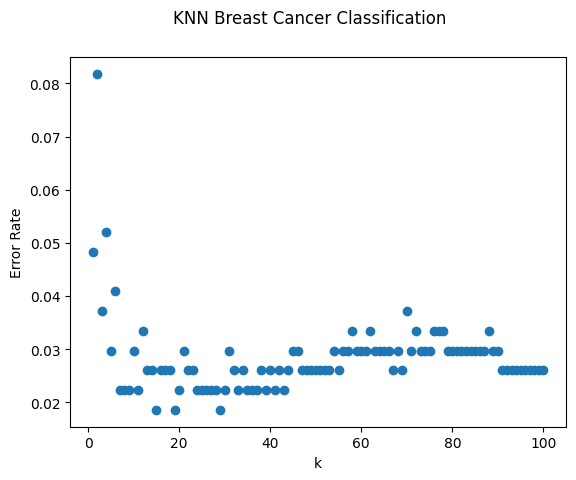

In [8]:
### PLOT COMPARISON ###
import matplotlib.pyplot as plt

plt.scatter(k_list,error_rate_k)
plt.suptitle('KNN Breast Cancer Classification')
plt.xlabel('k')
plt.ylabel('Error Rate')
plt.show()

### $k$-NN regression

Modify the $k$-NN implementation to do regression instead of classification. Compare the performance of the linear regression model and the $k$-NN regression model on the diabetes dataset for different values of $k$..

**SOLUTION:**

In [9]:
# start of with the same function
def knn_regression(x_test,X_train,y_train,k):
    # extract # of training samples and features
    n_train = X_train.shape[0]
    n_features = X_train.shape[1]

    # check if k > # of training samples
    if k > n_train:
        return print("Cannot use more neighbours than # training samples")

    # compute the distance between the test and train sample
    dx = np.abs(x_test - X_train[:,:])
    dx = np.sqrt(np.sum(dx**2,axis=1))
    
    # sort distance and return the indices
    short_ind = np.argsort(dx)
    
    # predict based on the closest training values (for given feature)
    y_predict = np.mean(y_train[short_ind[0:k]])
    
    # delete rounding output, we want regression not classification
    return y_predict

### COPY of the given code to recompute beta and load X_train etc.
# add subfolder that contains all the function implementations
# to the system path so we can import them
import sys
sys.path.append('code/')

# the actual implementation is in linear_regression.py,
# here we will just use it to fit a model
from linear_regression import *

# load the dataset
# same as before, but now we use all features
X_train = diabetes.data[:300, :]
y_train = diabetes.target[:300, np.newaxis]
X_test = diabetes.data[300:, :]
y_test = diabetes.target[300:, np.newaxis]

beta = lsq(X_train, y_train)
### END OF COPY

# possibly improve result by scaling features

k_list = []
avg_error_k = []
avg_error_b = []
# performance comparison rough
for k in range(100):
    error_k = 0
    error_b = 0
    for i in range(X_test.shape[0]):
        error_k = error_k + (knn_regression(X_test[i,:],X_train,y_train,k+1)-y_test[i])**2
        x_test = np.insert(X_test[i,:],0,1)
        error_b = error_b + (np.dot(x_test,beta)-y_test[i])**2
    avg_error_k.append(error_k/X_test.shape[0])
    avg_error_b.append(error_b/X_test.shape[0])
    k_list.append(k+1)



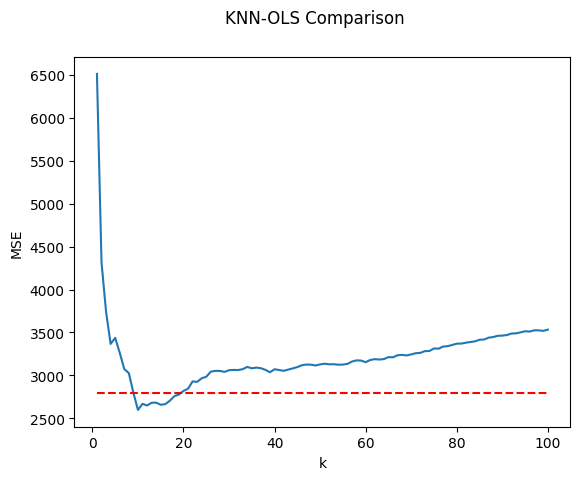

In [10]:
### PLOT COMPARISON ###
import matplotlib.pyplot as plt

plt.plot(k_list,avg_error_k,k_list,avg_error_b,'r--')
plt.suptitle('KNN-OLS Comparison')
plt.xlabel('k')
plt.ylabel('MSE')
plt.show()

### Class-conditional probability

Compute and visualize the class-conditional probability (conditional probability where the class label is the conditional variable, i.e. $P(X = x \mid Y = y_i)$ for all features in the breast cancer dataset. Assume a Gaussian distribution.

<p><font color='#770a0a'>Based on visual analysis of the plots, which individual feature can best discriminate between the two classes? Motivate your answer.</font></p>



**SOLUTION:**

Per feature $x$ we will obtain 2 Gaussian distributions for $Y=0$ and $Y=1$ $\left(P(X = x \mid Y = y_i)\right)$, the intersect of these distributions is calculated as:

$$\frac{1}{\sqrt{2\pi\sigma_0}}e^{-\frac{(x-\mu_0)^2}{2\sigma_0}}=\frac{1}{\sqrt{2\pi\sigma_1}}e^{-\frac{(x-\mu_1)^2}{2\sigma_1}}$$
$$\Rightarrow \ln\left({\frac{1}{\sqrt{2\pi\sigma_0}}}\right){-\frac{(x-\mu_0)^2}{2\sigma_0}}=
\ln\left({\frac{1}{\sqrt{2\pi\sigma_1}}}\right){-\frac{(x-\mu_1)^2}{2\sigma_1}}$$
$$\Rightarrow x^2\left(\frac{\sigma_1-\sigma_0}{\sigma_0\sigma_1}\right)+x\left(\frac{2\mu_1\sigma_0-2\mu_0\sigma_1}{\sigma_0\sigma_1}\right)+\left(\frac{\sigma_1\mu_0^2-\sigma_0\mu_1^2}{\sigma_0\sigma_1}+\ln\left(\frac{\sigma_0}{\sigma_1}\right)\right) = 0$$

, which is solvable with the quadratic formula. The intersection is used to compute the overlap $\Rightarrow$ a high overlap means low discrimination power, where a low overlap means a high discrimination power. The mean and standard deviation are calculated with built in Numpy functions.


Overlap[X=1] = 0.42944522540231594


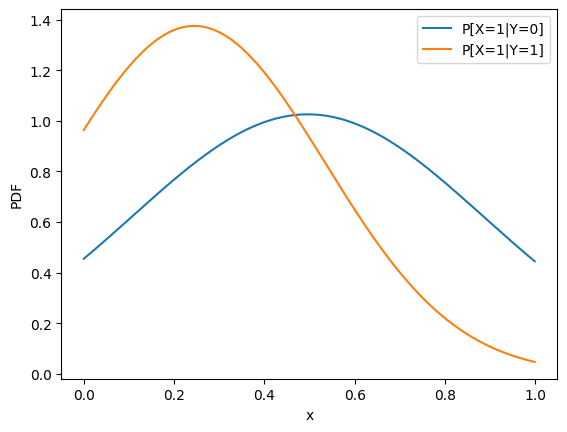

Overlap[X=2] = 0.638824564904588


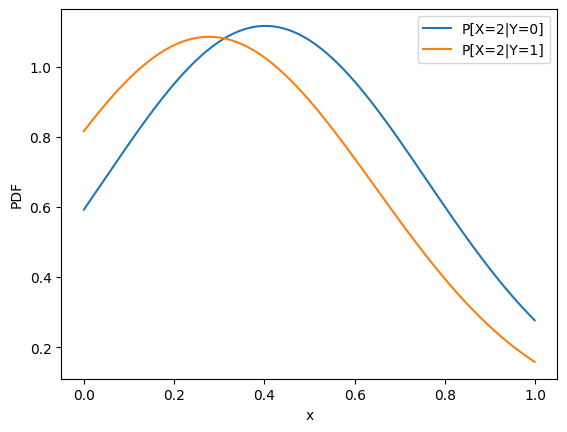

Overlap[X=3] = 0.41720482869088416


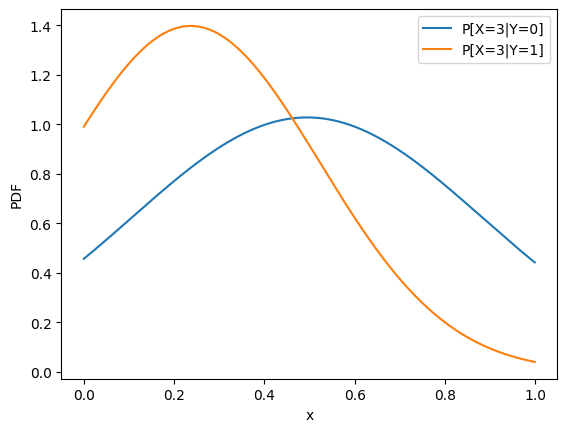

Overlap[X=4] = 0.5535620869918799


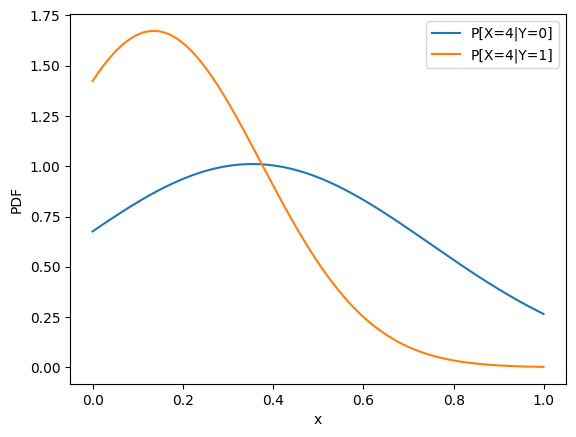

Overlap[X=5] = 0.6981395635357995


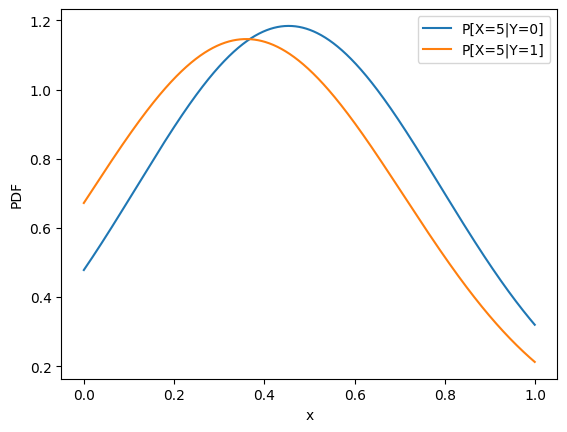

Overlap[X=6] = 0.5671335575110098


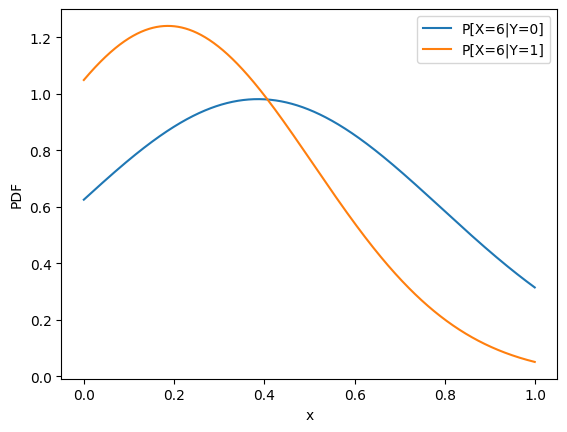

Overlap[X=7] = 0.43735388798691954


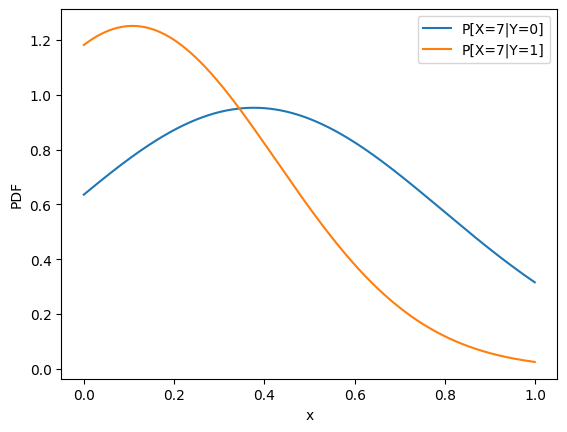

Overlap[X=8] = 0.36386340810683593


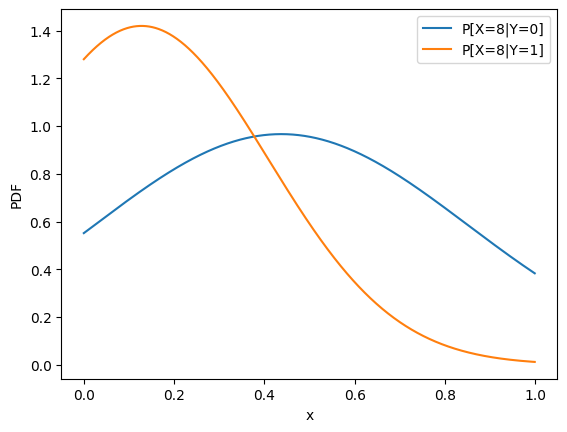

Overlap[X=9] = 0.7395168875008229


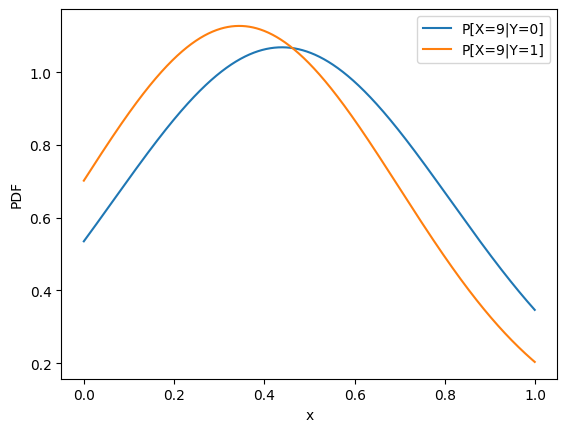

Overlap[X=10] = 0.990382579668349


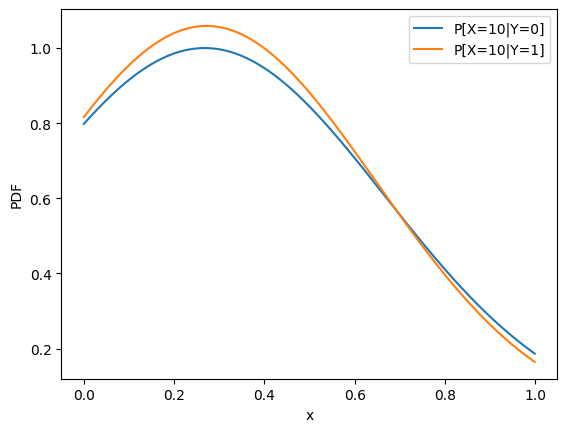

Overlap[X=11] = 0.7974633383633474


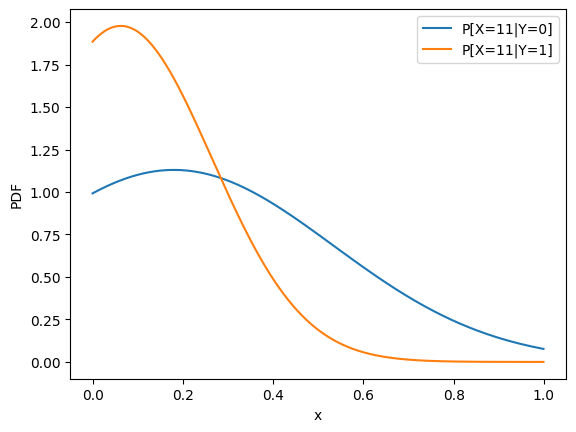

Overlap[X=12] = 0.9927318667869244


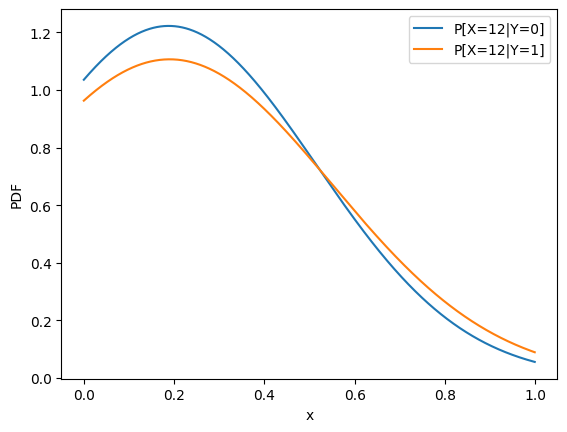

Overlap[X=13] = 0.8131926431936858


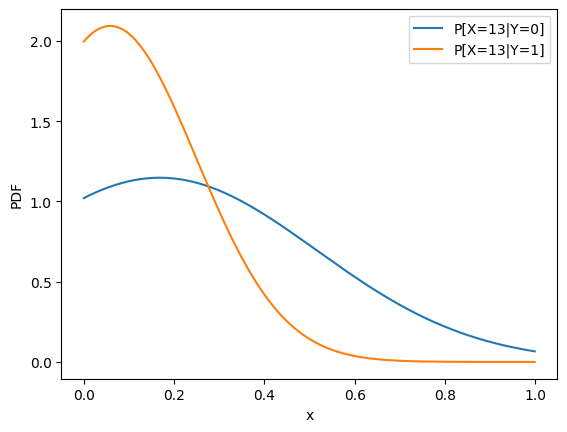

Overlap[X=14] = 0.7690326414681823


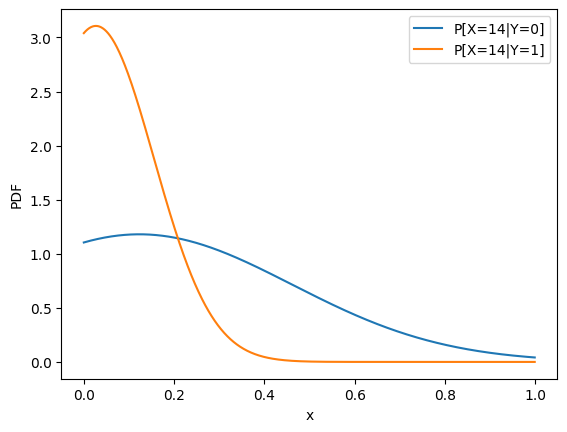

Overlap[X=15] = 0.9725441297297999


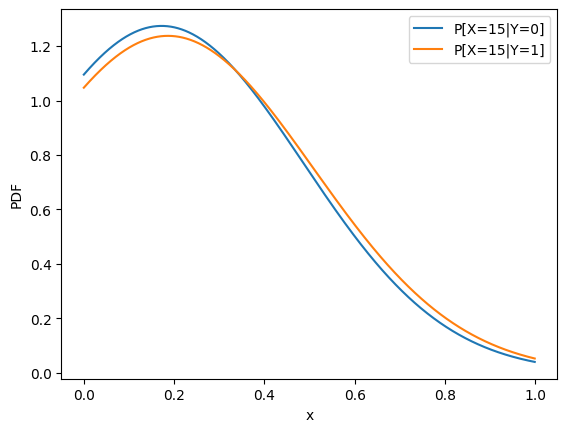

Overlap[X=16] = 0.7797258192026943


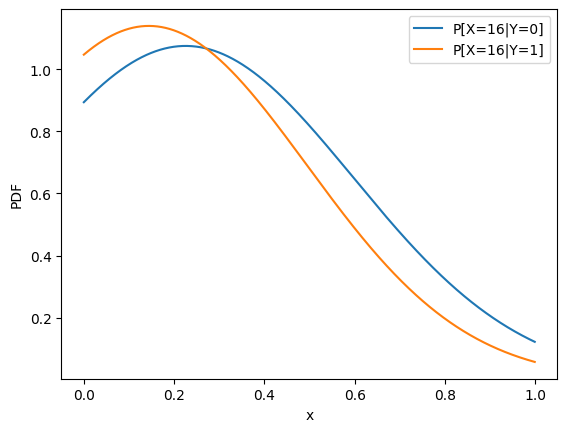

Overlap[X=17] = 0.9722553303170579


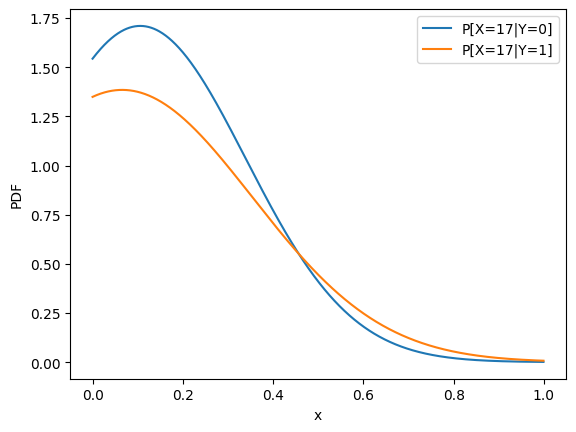

Overlap[X=18] = 0.6455891784626359


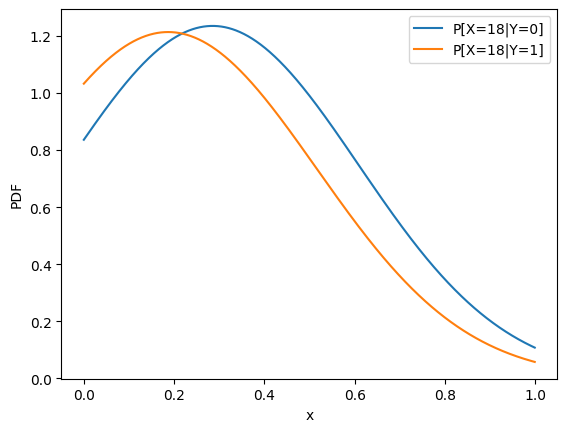

Overlap[X=19] = 0.9850628797065059


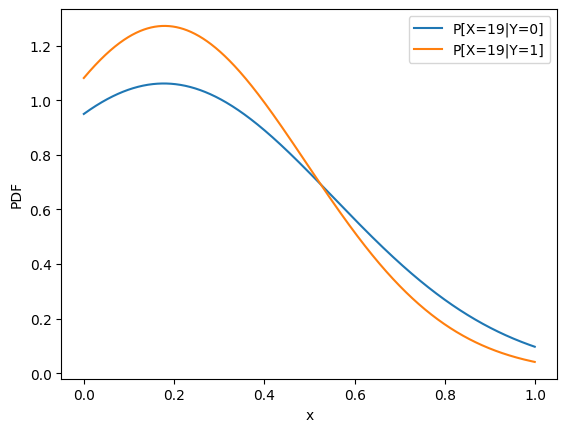

Overlap[X=20] = 0.9917779169075274


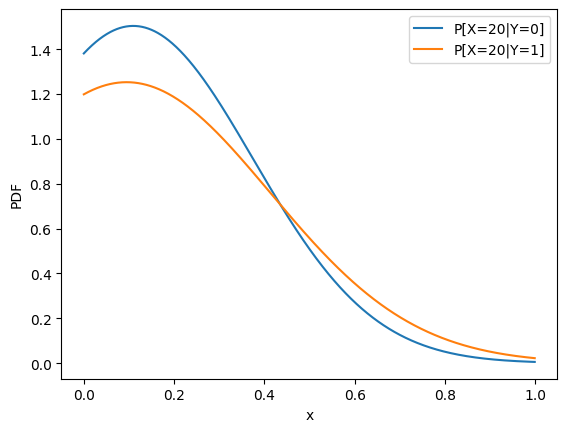

Overlap[X=21] = 0.3931851974846669


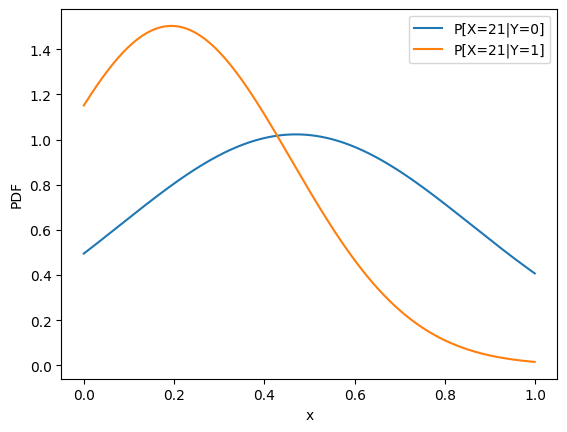

Overlap[X=22] = 0.5948563645040013


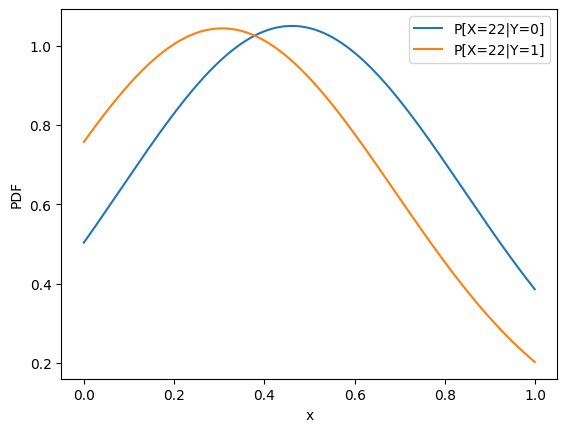

Overlap[X=23] = 0.3914612172111304


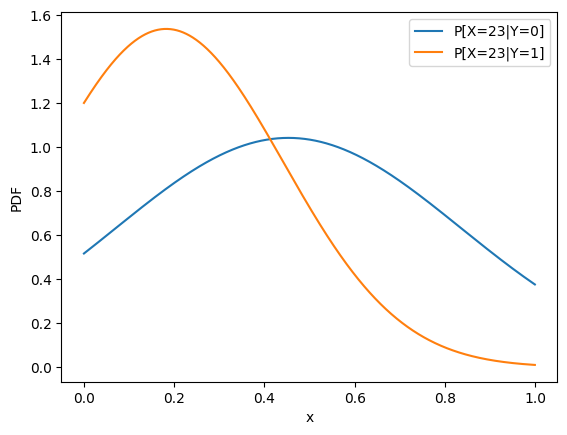

Overlap[X=24] = 0.5434244094749874


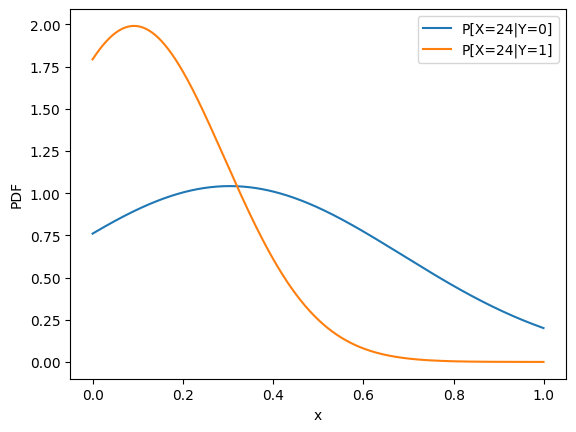

Overlap[X=25] = 0.6432321281207988


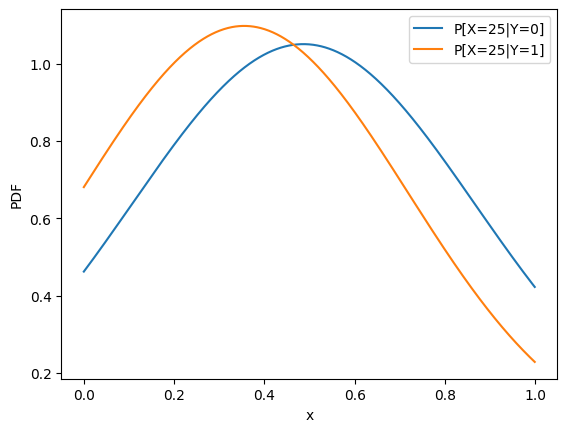

Overlap[X=26] = 0.6243703965124029


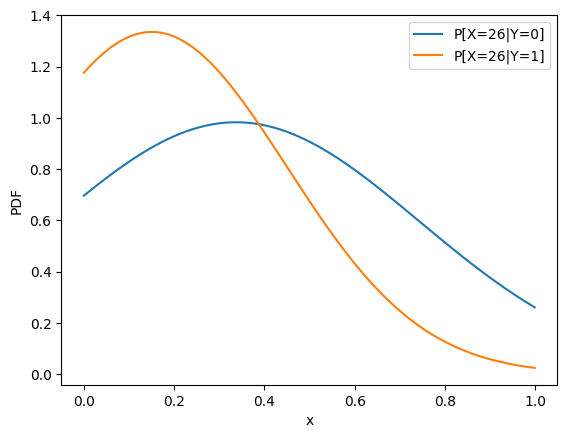

Overlap[X=27] = 0.41880014475389676


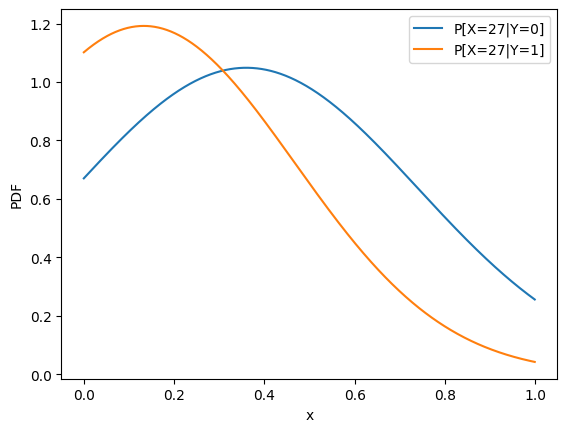

Overlap[X=28] = 0.2092218636926288


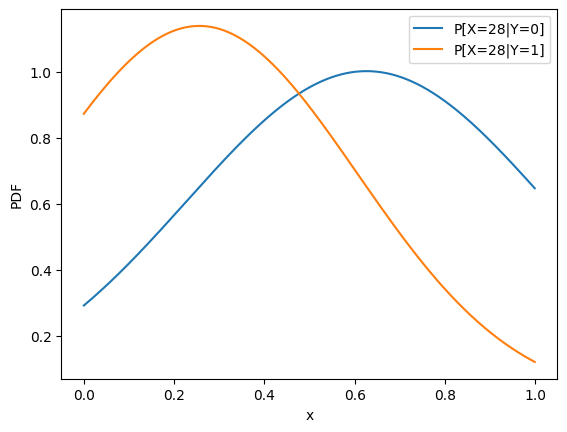

Overlap[X=29] = 0.8245981852859163


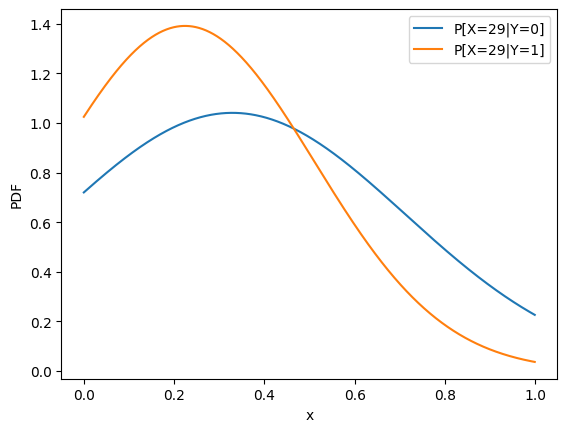

Overlap[X=30] = 0.8725174301529188


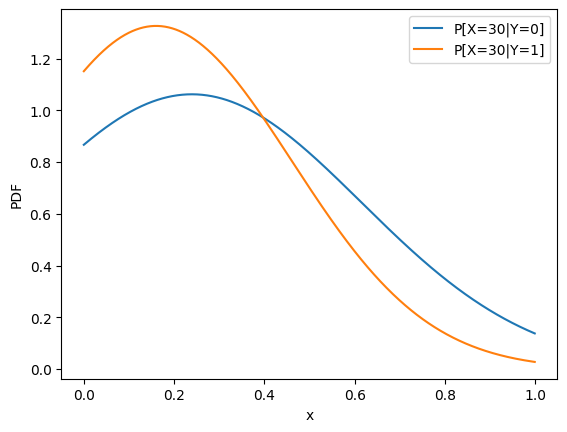

In [26]:
from scipy.stats import norm

# Obtain normalized data set
# normalize features to the [0,1] range
data = breast_cancer.data
for i in range(30):
    # subtract minimum
    data[:,i] = data[:,i]-np.min(data[:,i])
    # divide by maximum
    data[:,i] = data[:,i]/np.max(data[:,i])

# assign X and Y
X = data
y = breast_cancer.target[:,np.newaxis]

# find indices where y=0 or y=1
zero_ind = y == 0
one_ind = y == 1

# feature probabilty
f_overlap = []

# loop over the features
for f in range(X.shape[1]):
    # define x with given feature
    x = X[:,f]
    x = x[:,np.newaxis]

    # mean and std of y=0
    mu_0 = np.mean(x[zero_ind])
    sigma_0 = np.std(x[zero_ind])

    # mean and std of y=1
    mu_1 = np.mean(x[one_ind])
    sigma_1 = np.std(x[one_ind])

    # calculate polynomial coefs according to intersection derivation
    a = (sigma_1-sigma_0)/(sigma_0*sigma_1)
    b = (2*mu_1*sigma_0-2*mu_0*sigma_1)/(sigma_0*sigma_1)
    c = (sigma_1*mu_0**2-sigma_0*mu_1**2)/(sigma_0*sigma_1) + np.log(sigma_0/sigma_1)

    # create the polynomial
    p = np.polynomial.polynomial.Polynomial([c,b,a])

    # calcuate the roots
    roots = p.roots()

    # check which gaussian is greater in between roots
    peak_0 = 1/np.sqrt(2*np.pi*sigma_0)*np.exp(-(np.mean(roots)-mu_0)**2/(2*sigma_0))
    peak_1 = 1/np.sqrt(2*np.pi*sigma_1)*np.exp(-(np.mean(roots)-mu_1)**2/(2*sigma_1))

    # act accordingly
    if peak_0 > peak_1:
        # area left of root
        area_l = norm.sf(roots[1], loc=mu_0,scale=sigma_0)
        # area right of root
        area_r = 1 - norm.sf(roots[0], loc=mu_0,scale=sigma_0)
        # area in the center
        area_c = norm.sf(roots[0], loc=mu_1,scale=sigma_1) - norm.sf(roots[1], loc=mu_1,scale=sigma_1)
    else:
        # area left of root
        area_l = norm.sf(roots[1], loc=mu_1,scale=sigma_1)
        # area right of root
        area_r = 1 - norm.sf(roots[0], loc=mu_1,scale=sigma_1)
        # area in the center
        area_c = norm.sf(roots[0], loc=mu_0,scale=sigma_0) - norm.sf(roots[1], loc=mu_0,scale=sigma_0)

    # calculate overlap on intersect area
    overlap = (area_l+area_r+area_c)
    f_overlap.append(overlap)
    
    # print the calculated probability
    print("Overlap[X="+str(f+1)+"] = "+str(overlap))
    
    # create plot arrays
    x_axis = np.arange(0, 1, 0.001)
    y_axis_0 = 1/np.sqrt(2*np.pi*sigma_0)*np.exp(-(x_axis-mu_0)**2/(2*sigma_0))
    y_axis_1 = 1/np.sqrt(2*np.pi*sigma_1)*np.exp(-(x_axis-mu_1)**2/(2*sigma_1))
    
    # plot the pfd's of y=0, y=1 for feature x=f
    plt.plot(x_axis,y_axis_0,x_axis,y_axis_1)
    plt.xlabel("x")
    plt.ylabel("PDF")
    plt.legend(["P[X="+str(f+1)+"|Y=0]","P[X="+str(f+1)+"|Y=1]"])
    plt.show()



In [21]:
# sort the probabilities
# create sorted list of the probabilties
f_ind = np.argsort(f_overlap)
for i in range(X.shape[1]):
    print("Overlap[X="+str(f_ind[i]+1)+"]\t= "+str(f_overlap[f_ind[i]]))

Overlap[X=28]	= 0.2092218636926288
Overlap[X=8]	= 0.36386340810683593
Overlap[X=23]	= 0.3914612172111304
Overlap[X=21]	= 0.3931851974846669
Overlap[X=3]	= 0.41720482869088416
Overlap[X=27]	= 0.41880014475389676
Overlap[X=1]	= 0.42944522540231594
Overlap[X=7]	= 0.43735388798691954
Overlap[X=24]	= 0.5434244094749874
Overlap[X=4]	= 0.5535620869918799
Overlap[X=6]	= 0.5671335575110098
Overlap[X=22]	= 0.5948563645040013
Overlap[X=26]	= 0.6243703965124029
Overlap[X=2]	= 0.638824564904588
Overlap[X=25]	= 0.6432321281207988
Overlap[X=18]	= 0.6455891784626359
Overlap[X=5]	= 0.6981395635357995
Overlap[X=9]	= 0.7395168875008229
Overlap[X=14]	= 0.7690326414681823
Overlap[X=16]	= 0.7797258192026943
Overlap[X=11]	= 0.7974633383633474
Overlap[X=13]	= 0.8131926431936858
Overlap[X=29]	= 0.8245981852859163
Overlap[X=30]	= 0.8725174301529188
Overlap[X=17]	= 0.9722553303170579
Overlap[X=15]	= 0.9725441297297999
Overlap[X=19]	= 0.9850628797065059
Overlap[X=10]	= 0.990382579668349
Overlap[X=20]	= 0.99177791

Based on the visualisation of the PDF of a given feature and the sorted list, it is evident that features $x$ in which the standard deviation and mean of $Y=y_i$ are similar, i.e. they have great overlap, there is less chance of predicting $Y$, e.g. $X=12$ given a certain $x$. Whereas PDF's with little overlap, e.g. $X=28$, have greater chance of predicting $Y$.